In [ ]:
!nvidia-smi

Thu May 28 15:53:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install package-name

In [ ]:
from google.colab import files
uploaded = files.upload()

Exercise 4

In [2]:
# task 1
import numpy as np

# Create a 5x5 matrix of ones
matrix = np.ones((5, 5))

# Set the interior to zero
matrix[1:4, 1:4] = 0

print(matrix)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [4]:
# task 2
np.random.seed(42)
random_data = np.random.randn(100, 3)

normalized_data = (random_data - random_data.mean(axis=0))/random_data.std(axis=0)

print(normalized_data.mean(axis=0))
print(normalized_data.std(axis=0))

[-2.60902411e-17  1.55431223e-17 -8.88178420e-18]
[1. 1. 1.]


In [5]:
# task 3
X = np.random.randn(50, 3)

true_theta = np.array([2.5, -1.2, 3.7])

y = X @ true_theta + np.random.randn(50) * 0.1

theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:")
print(theta_hat)

print("\nTrue coefficients:")
print(true_theta)

Estimated coefficients:
[ 2.51723721 -1.19783796  3.72399266]

True coefficients:
[ 2.5 -1.2  3.7]


Exercise 5

In [14]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset
print(df.info())
# TODO: Identify and count missing values
print('missing values')
print(df.isnull().sum())
# TODO: Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df.groupby("major")["exam_score"].transform(lambda x: x.fillna(x.mean()))
# TODO: Fill missing hours_studied with the median for the student's year
df["hours_studied"] = df.groupby("year")["hours_studied"].transform(lambda x: x.fillna(x.median()))

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
average_score_by_major = df.groupby("major")["exam_score"].mean()
print("Average exam score by major: ")
print(average_score_by_major)
# TODO: Find the major with the highest average exam_score
best_major = average_score_by_major.idxmax()
print("Major with highest average score: ")
print(best_major)
# TODO: Calculate the correlation between hours_studied and exam_score
correlation = df["hours_studied"].corr(df["exam_score"])
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
print("Correlation between study hours and exam score:",correlation)
# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
df["performance"] = pd.cut(df["exam_score"],bins=[0, 70, 80, 90, 100],
        labels=[
        "Needs Improvement",
        "Average",
        "Good",
        "Excellent"],
    include_lowest=True)
print(df[["exam_score", "performance"]].head())
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_5_students = df.nlargest(5, "exam_score")
print("\n")
print("The top 5 students are:",top_5_students)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = pd.pivot_table(df,values="exam_score",index="major",columns="year",aggfunc="mean")
print("Pivot Table: ",pivot_table)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
missing values
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
Average exam score by major: 
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Major with highest average score: 
CS
Correlation between study 

Exercise 6

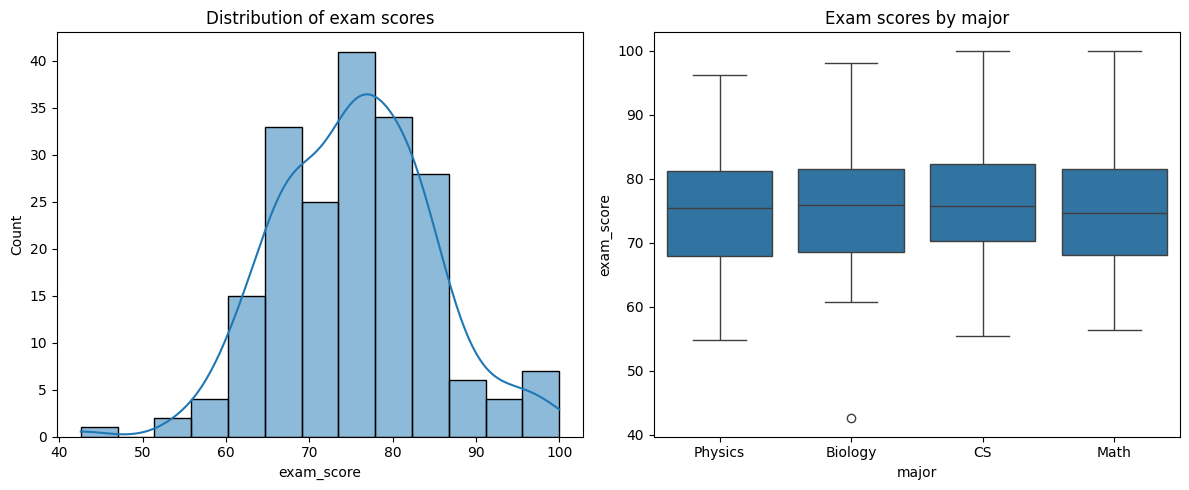

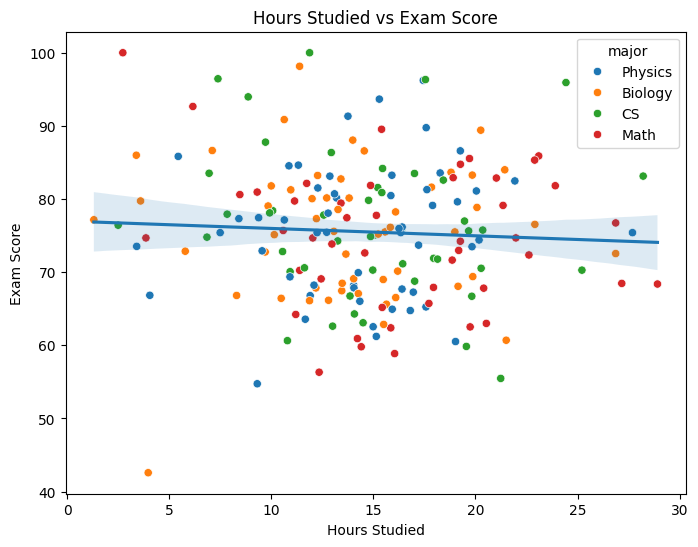

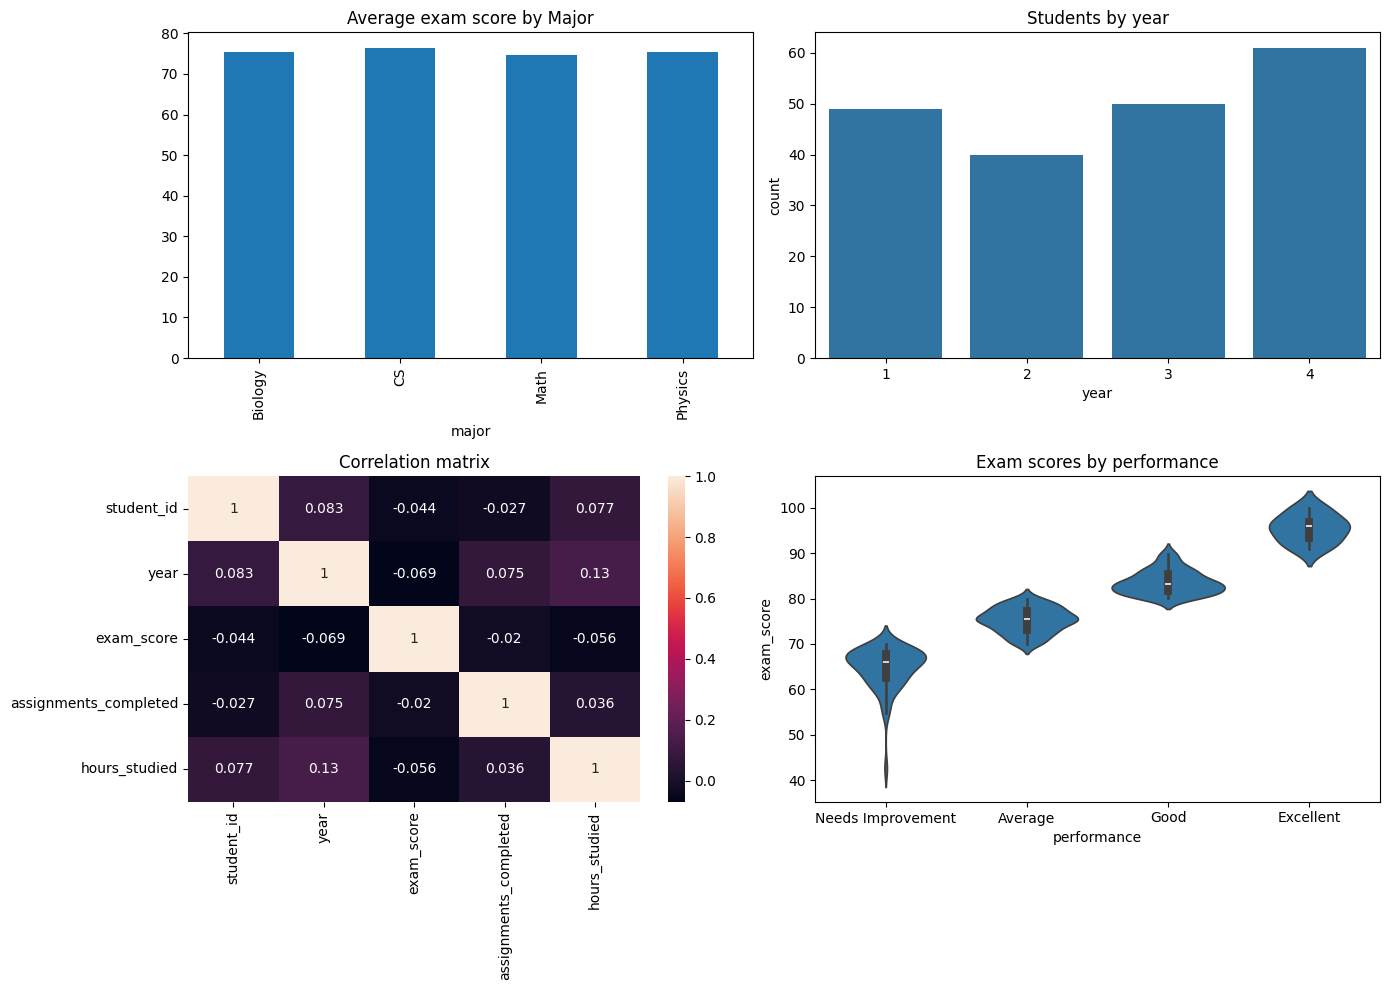

In [17]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""

import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of exam scores")
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="major", y="exam_score")
plt.title("Exam scores by major")
plt.tight_layout()
plt.show()
# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    hue="major")

sns.regplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    scatter=False)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()
# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
average_score_by_major.plot(
    kind="bar",
    ax=axes[0, 0],
    title="Average exam score by Major")

# 2. Count plot: Number of students by year
sns.countplot(
    data=df,
    x="year",
    ax=axes[0, 1])
axes[0, 1].set_title("Students by year")

# 3. Heat map: Correlation matrix of numerical columns
numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    ax=axes[1, 0])

axes[1, 0].set_title("Correlation matrix")

# Violin plot: Exam score distribution by performance category
sns.violinplot(
    data=df,
    x="performance",
    y="exam_score",
    ax=axes[1, 1])

axes[1, 1].set_title("Exam scores by performance")

plt.tight_layout()
plt.show()

Exercesise 7

           number_of_customers  average_income  average_CLV      total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747.738562   54584.915035
36-50                      160    48516.895668   732.796612  117247.457917
51-70                      186    50713.163384   762.693498  141860.990683
    age        income  purchase_frequency  avg_purchase_value          CLV  \
6    38  58876.388563                  10          110.331527  1287.201143   
9    40  48809.492879                  10          110.228581  1286.000108   
19   41  21282.756976                   8          119.651218  1276.279663   
24   38  53981.193911                   8          120.320786  1283.421714   
57   64  45956.146951                   7          135.470585  1343.416638   

   age_group  
6      36-50  
9      36-50  
19     36-50  
24     36-50  
57    

/tmp/ipykernel_9860/1469791405.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_analysis = customers.groupby("age_group").agg(


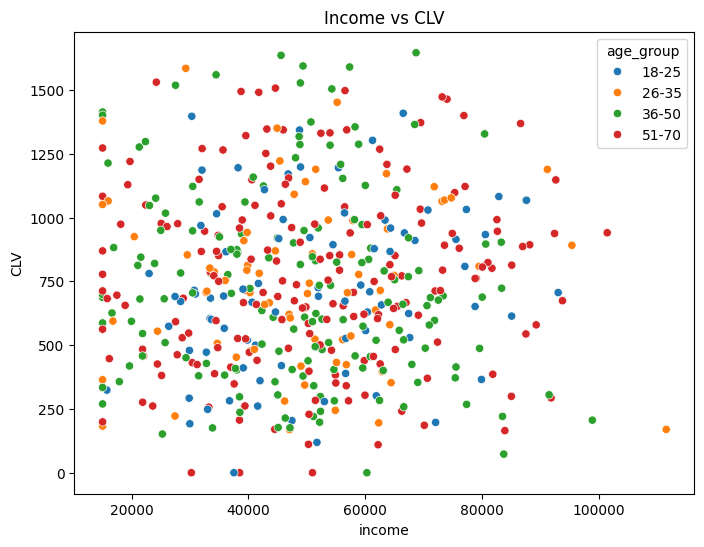

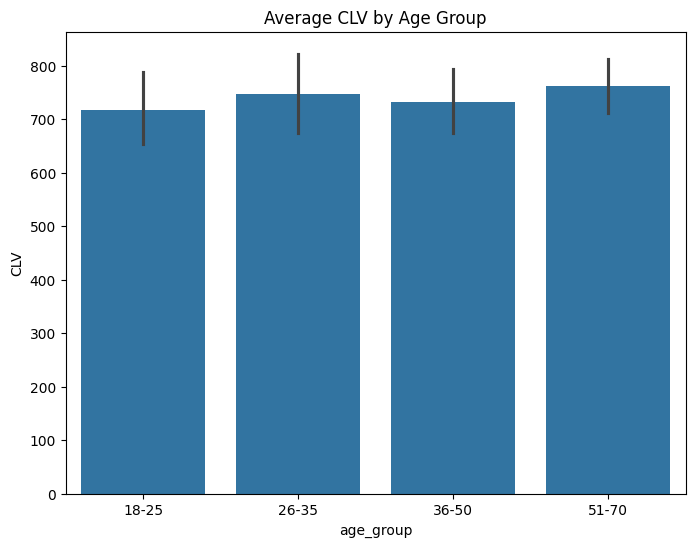

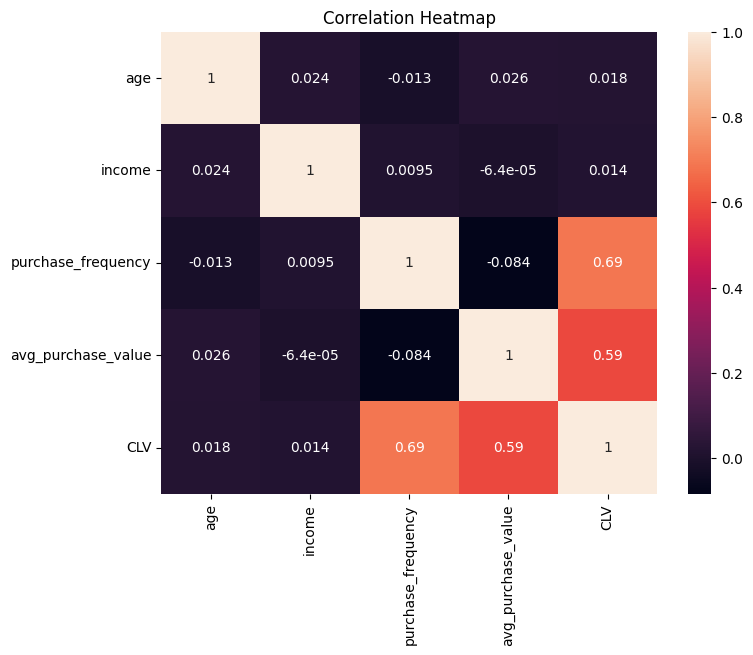

'\nAfter analyzing the data, the key insights show that the clv or customer life value increases with purchase frequency, due to frequent buyers contributing more revenue over time. Income has a positive relationship with customer lifetime value. The age group analysis shows the differences in the average customer life value across different segments. This shows that some age groups are more valuable to the business than others. My recommendation will be that the company should focus on the more valuable customers, which are the customers with higher customer lifetime value and also market differently to different age groups, spending more on the age groups that have high customer lifetime value.\n'

In [24]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

#churn risk
max_frequency = purchase_freq.max()
churn_risk = 1 - (purchase_freq / max_frequency)

#CLV
customers["CLV"] = (
    customers["purchase_frequency"]
    * customers["avg_purchase_value"]
    * (1 + churn_risk))

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers["age_group"] = pd.cut(
    customers["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
    include_lowest=True)
# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
group_analysis = customers.groupby("age_group").agg(
    number_of_customers=("age", "count"),
    average_income=("income", "mean"),
    average_CLV=("CLV", "mean"),
    total_CLV=("CLV", "sum"))
print(group_analysis)
# TODO: Identify top 10% of customers by CLV
threshold = customers["CLV"].quantile(0.90)
top_customers = customers[customers["CLV"] >= threshold]
print(top_customers.head())
# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap

#1. Scatter plot of income vs CLV (color by age group)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=customers,
    x="income",
    y="CLV",
    hue="age_group")
plt.title("Income vs CLV")
plt.show()

#2. Bar chart of average CLV by age group
plt.figure(figsize=(8, 6))
sns.barplot(
    data=customers,
    x="age_group",
    y="CLV")
plt.title("Average CLV by Age Group")
plt.show()

#3. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    customers.select_dtypes(include=np.number).corr(),
    annot=True)
plt.title("Correlation Heatmap")
plt.show()
# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
"""After analyzing the data, the key insights show that the clv or customer life value increases with purchase frequency, due to frequent buyers contributing more revenue over time. Income has a positive relationship with customer lifetime value. The age group analysis shows the differences in the average customer life value across different segments. This shows that some age groups are more valuable to the business than others. My recommendation will be that the company should focus on the more valuable customers, which are the customers with higher customer lifetime value and also market differently to different age groups, spending more on the age groups that have high customer lifetime value.
"""